In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy.stats import norm
import math

nfx = pd.read_csv("netflix_titles.csv")

In [10]:
nfx.shape

(8807, 12)

In [11]:
only_movies_duration = nfx.loc[(nfx.type == "Movie" ),"duration"]
only_movies_duration.isnull().sum()
only_movies_duration = only_movies_duration.fillna(0)

<Axes: xlabel='duration', ylabel='Count'>

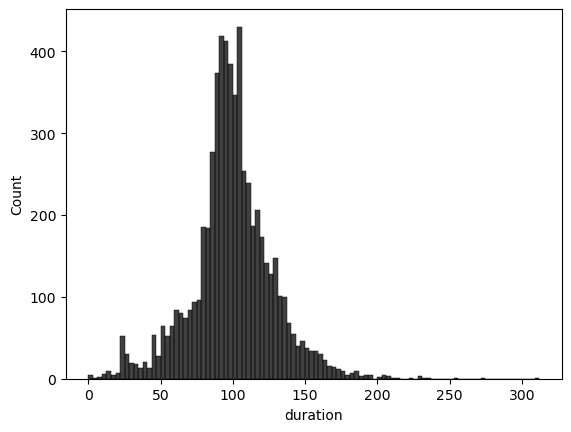

In [17]:
def remove_min(rows):
     a = str(rows)
     mi = a.replace("min", '').strip()
     return int(mi)

ee = only_movies_duration.apply(remove_min)

sns.histplot(ee, bins=100,color="black")

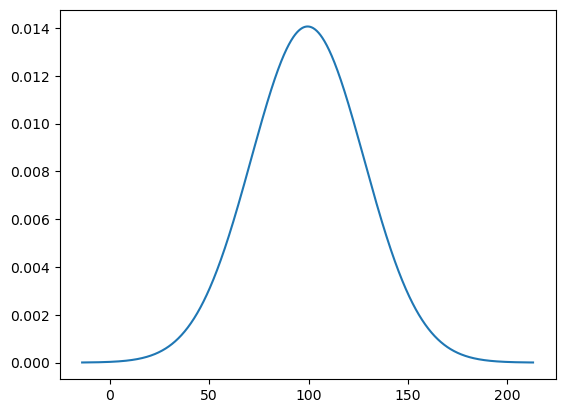

In [18]:
# Probability destiny function centers around 100
mu = ee.mean()
sigma = ee.std()

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.plot(x,y)

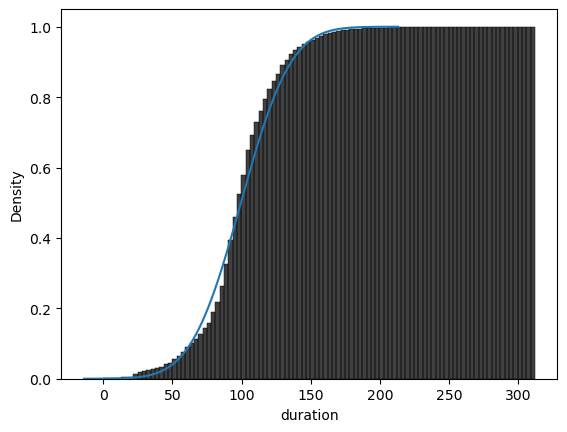

In [28]:
# Cumulative destiny function centers around 100
mu = ee.mean()
sigma = ee.std()

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.cdf(x, mu, sigma)

sns.histplot(ee, bins=100,color="black",cumulative=True, stat="density")
plt.plot(x, y)  
plt.show()  
#plt.plot(x,y)

<Axes: xlabel='release_year', ylabel='count'>

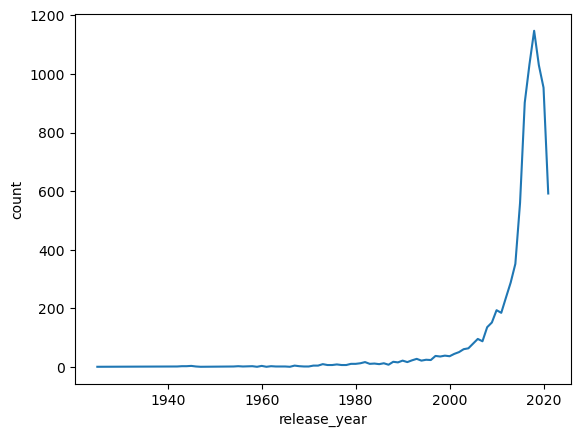

In [23]:
title_release = nfx.loc[:,["title","release_year"]]

from_2000 = title_release[title_release.release_year >= 2000]
x = from_2000["release_year"].value_counts().sort_index()
overall = title_release["release_year"].value_counts().sort_index()

sns.lineplot(data=overall)

In [46]:
# get a Sample size

random_sam = ee.sample(n=100,random_state=1)
#print(random_sam.mean())
#print(random_sam.std())
#sns.histplot(random_sam, bins=50,color="black")
type(random_sam)


pandas.core.series.Series